In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import run_fair

import utils_MLP

import seaborn as sns
from cmcrameri import cm

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

## 1. Create CO<sub>2</sub>-only scenarios
### 1a. Training scenario setup

In [50]:
# Required parameters
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
agents = ['CO2','CH4','N2O','Sulfur','BC']
emis_dict = run_fair.load_cmip7_extensions(n_steps, agents)

# Combined steps
step_dict = {}
for i, a in enumerate(agents):
  year_step = i * 50
  step = np.zeros(n_steps)
  step[year_step:] = 10
  step_dict[a] = step
emis_dict['step'] = run_fair.ensure_all_agents(step_dict, n_steps)

# Combined pulses
pulse_dict = {}
for i, a in enumerate(agents):
  year_pulse = i * 50
  pulse = np.zeros(n_steps)
  pulse[year_pulse] = 1000
  pulse_dict[a] = pulse
emis_dict['pulse'] = run_fair.ensure_all_agents(pulse_dict, n_steps)


In [42]:
# Noise
sigma = 100 # Noise standard deviation
n = 5
u = utils_MLP.generate_uncorrelated_signals(n, n_steps)
utils_MLP.verify(u)
noise_co2, noise_ch4, noise_n2o, noise_so2, noise_bc = u
emis_dict['noise'] = run_fair.ensure_all_agents({'CO2': sigma*noise_co2,
                                                 'CH4': sigma*noise_ch4,
                                                 'N2O': sigma*noise_n2o,
                                                 'Sulfur': sigma*noise_so2,
                                                 'BC': noise_bc}, n_steps)


Verifying Correlation (dot products of e_i, e_j for i!=j should be close to 0.0):
  <e_1, e_2>: -0.000000
  <e_1, e_3>:  0.000000
  <e_1, e_4>: -0.000000
  <e_1, e_5>:  0.000000
  <e_2, e_3>: -0.000000
  <e_2, e_4>: -0.000000
  <e_2, e_5>: -0.000000
  <e_3, e_4>:  0.000000
  <e_3, e_5>:  0.000000
  <e_4, e_5>: -0.000000


In [ ]:
#DECK =
#AerChemMIP =
#CDRMIP =
#GeoMIP =

In [51]:
scenarios_all = list(emis_dict.keys())

### 1c. Force FaIR with scenarios to get $\overline{\Delta T}(t)$

In [58]:
nan_force = np.zeros(n_steps)
delT_train_dict_priority_1 = {}
delT_test_dict_priority_2 = {}
agents = ['CO2','CH4','N2O','Sulfur','BC']
CMIP7_priority_1 = ['HO','HE','VL','VLO','L','ME','MO']
CMIP7_priority_1_ext = ['HE','VL']
CMIP7_priority_2_ext = ['HO','VLO','L','ME','MO']
idealized_test = ['pulse','step','noise']

for scen in scenarios_all:
  f = run_fair.build_fair(start, stop, input_mode="emissions")
  emis = {a: nan_force for a in agents}

  for agent in agents:
    emis[agent] = emis_dict[scen][agent]

  run_fair.reset_state(f)
  run_fair.set_emissions(f, years, emis)
  _, T, T_mean, _ = run_fair.run_fair(f, years)

  if (scen in CMIP7_priority_1 and scen in CMIP7_priority_1_ext):
    delT_train_dict_priority_1[scen] = T_mean
  elif scen in CMIP7_priority_1:
    delT_train_dict_priority_1[scen] = T_mean[:400]

  if scen in CMIP7_priority_2_ext or (scen in idealized_test):
    delT_test_dict_priority_2[scen] = T_mean

In [59]:
scenarios_train = [scen for scen in delT_train_dict_priority_1.keys()]
scenarios_test = [scen for scen in delT_test_dict_priority_2.keys()]

emis_dict_train, emis_dict_test = {}, {}
for scen in scenarios_train:
  emis_dict_train[scen] = {}
  for agent in agents:
    if (scen in CMIP7_priority_1 and scen in CMIP7_priority_1_ext):
      emis_dict_train[scen][agent] = emis_dict[scen][agent].copy()
    elif scen in CMIP7_priority_1:
      emis_dict_train[scen][agent] = emis_dict[scen][agent][:400].copy()

for scen in scenarios_test:
  emis_dict_test[scen] = {}
  for agent in agents:
    if scen in CMIP7_priority_2_ext or scen in idealized_test:
      emis_dict_test[scen][agent] = emis_dict[scen][agent].copy()

#### Optional: plot training scenarios

Text(0.5, 0, 'Year')

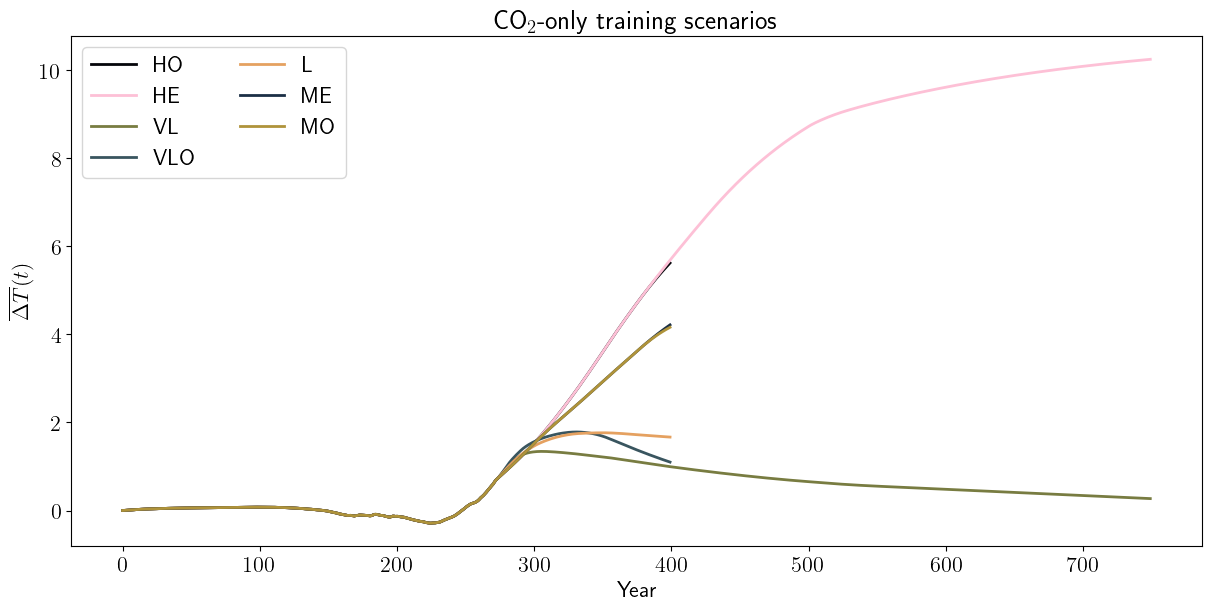

In [60]:
fig, ax = plt.subplots(figsize=(12,6), constrained_layout=True)
for i, scen in enumerate(delT_train_dict_priority_1.keys()):
  if scen in ['pulse','step','sine','noise']:
    ls = '--'
  else:
    ls = '-'
  ax.plot(delT_train_dict_priority_1[scen], label=scen, ls=ls, lw=2, c=cm.batlowKS(i))
  #ax.plot(emis_dict_train[scen]['BC'], label=scen, ls=ls, lw=2, c=cm.batlowKS(i))
ax.legend(loc='upper left', ncol=2)
ax.set_title(r'CO$_2$-only training scenarios')
ax.set_ylabel(r'$\overline{\Delta T}(t)$')
ax.set_xlabel('Year')

## 2. Evaluate emulator performance
### 2a. Train MLPs with each individual experiment

In [61]:
series_train, series_test = [], []
for scen in scenarios_train:
  series_train.append((emis_dict_train[scen], delT_train_dict_priority_1[scen]))
for scen in scenarios_test:
  series_test.append((emis_dict_test[scen], delT_test_dict_priority_2[scen]))

error_dict_single, yhat_dict_single = utils_MLP.evaluate_trainsets_vs_tests(scenarios_train, series_train, scenarios_test, series_test, agents, n_lags=10, random_state=0)

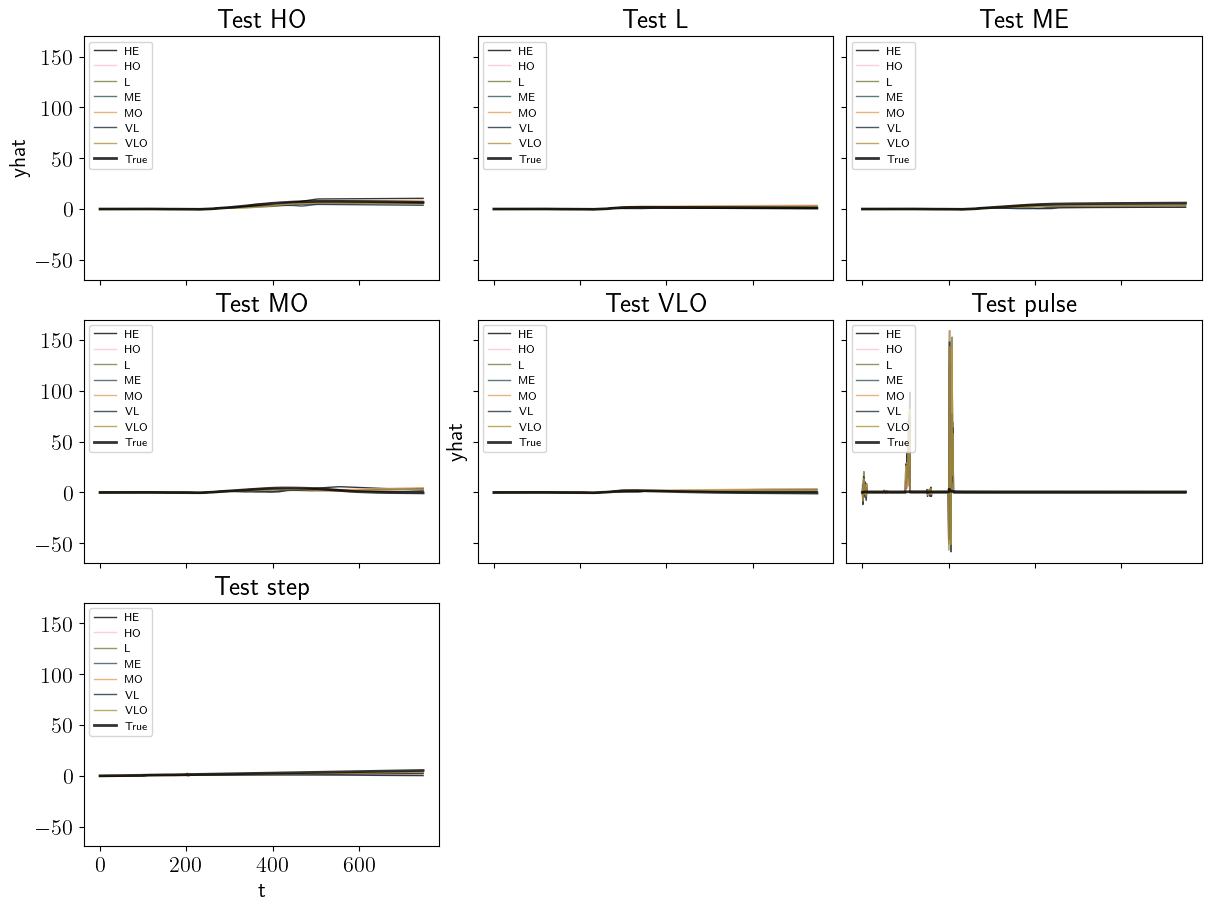

In [62]:
utils_MLP.plot_yhats_grid(error_dict_single, yhat_dict_single, delT_test_dict_priority_2)

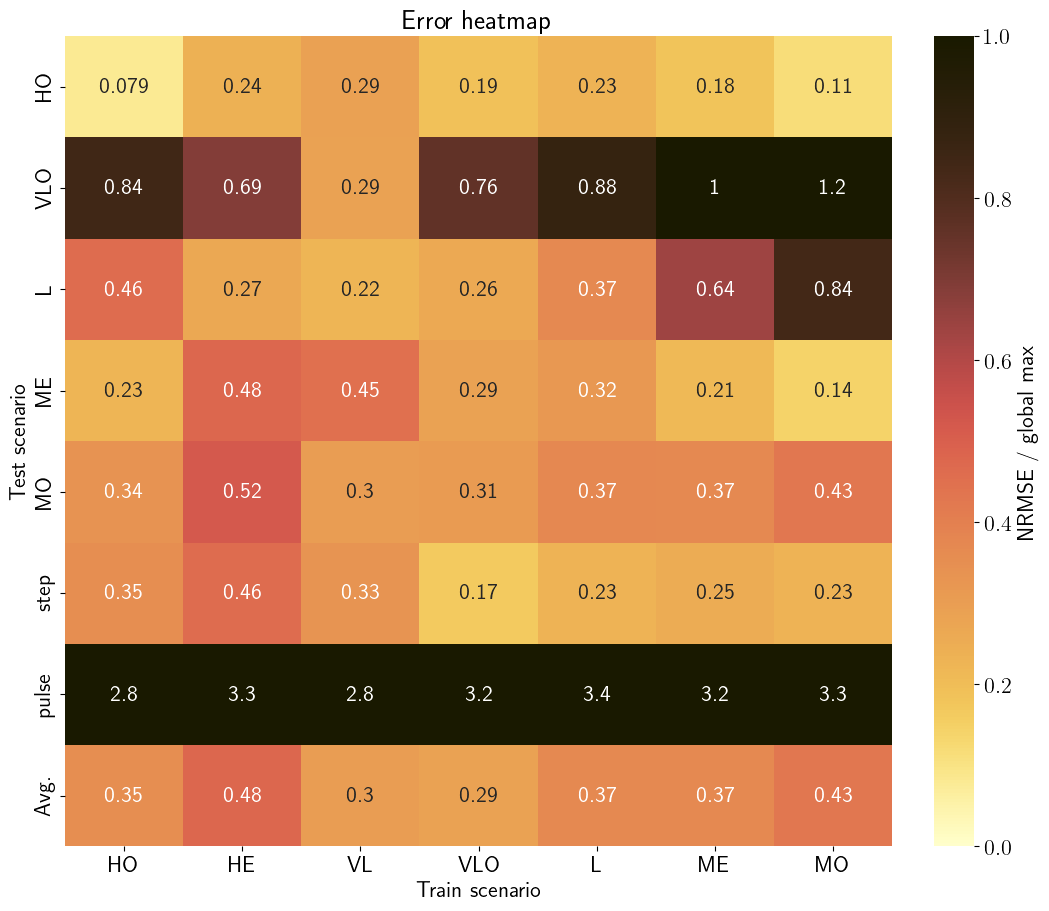

In [63]:
utils_MLP.plot_error_heatmap(error_dict_single, scenarios_train, scenarios_test)

### 2b. Train MLPs w/ multiple scenarios

In [64]:
training_groups = {'Bracket':['HE','VL']}
training_groups['All_CMIP7'] = CMIP7_priority_1.copy()

for scen in CMIP7_priority_1:
  key = f'Hold_{scen}'
  value = [tag for tag in CMIP7_priority_1 if tag != scen]
  training_groups[key] = value

#training_groups['noise'] = ['noise']
#training_groups['sine'] = ['sine']

error_dict_multi, yhat_dict_multi = utils_MLP.evaluate_trainsets_vs_tests(scenarios_train, series_train, scenarios_test, series_test, training_groups=training_groups, n_lags=10, random_state=0)

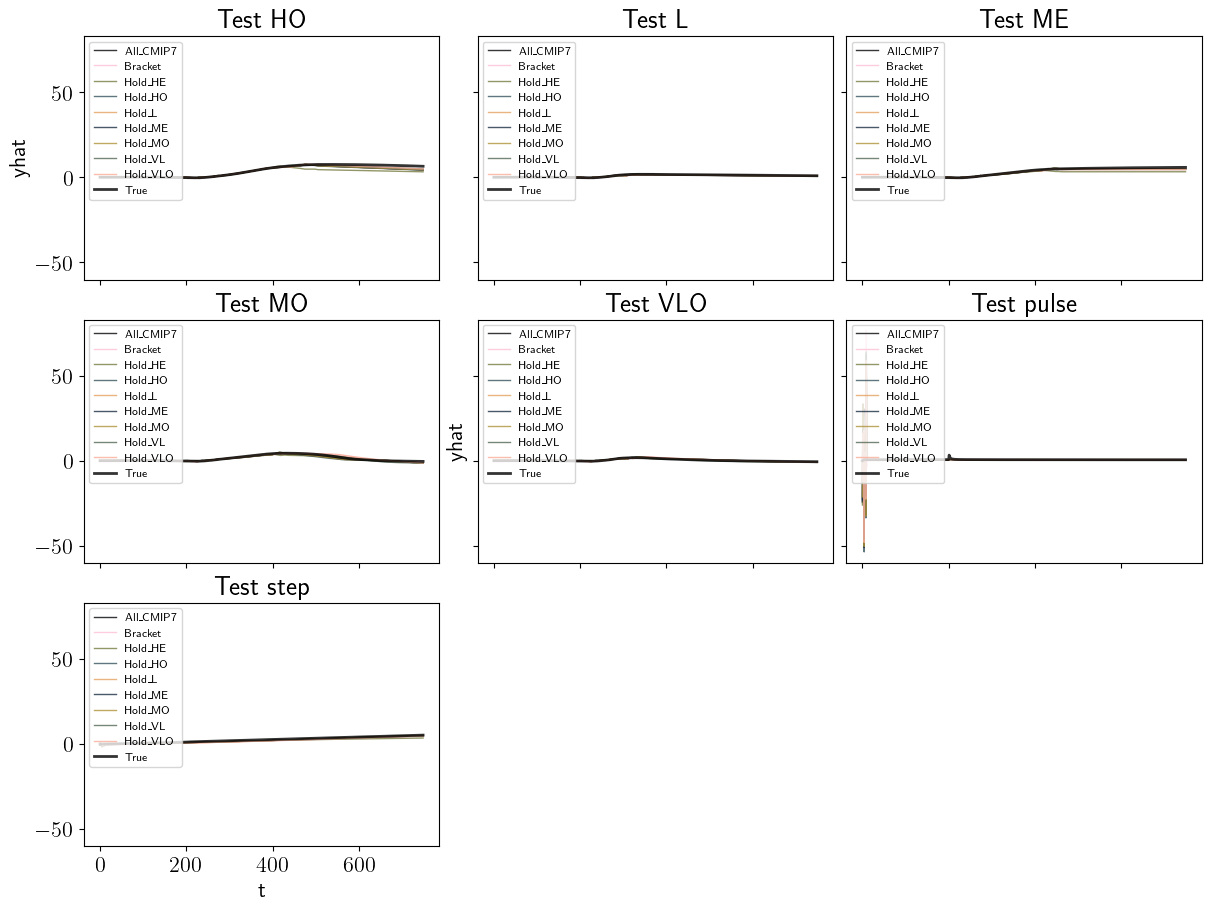

In [65]:
utils_MLP.plot_yhats_grid(error_dict_multi, yhat_dict_multi, delT_test_dict_priority_2)

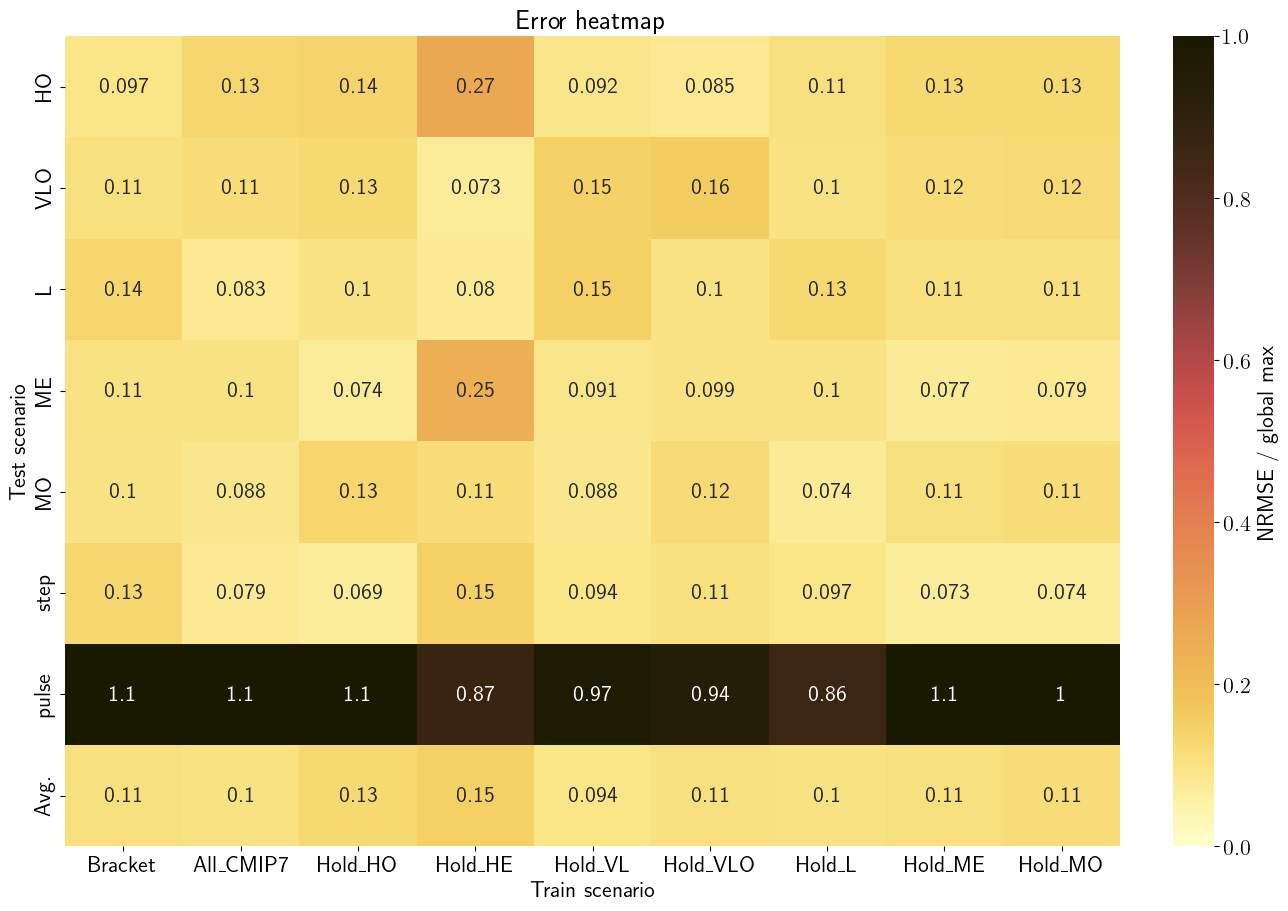

In [66]:
scenarios_train_multi = list(training_groups.keys())
utils_MLP.plot_error_heatmap(error_dict_multi, scenarios_train_multi, scenarios_test)